In [18]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Thêm thư mục gốc vào đường dẫn hệ thống để import được src
sys.path.append(os.path.abspath('..'))

# Import các module bạn vừa viết
from src.data.loader import DataLoader
from src.mining.association import AssociationMiner
from src.mining.clustering import ClusterMiner

# Cấu hình hiển thị
sns.set(style="whitegrid")

In [3]:
# Load dữ liệu từ folder data/raw
DATA_PATH = '../data/raw/ai4i2020.csv'
loader = DataLoader(DATA_PATH)
df = loader.load_data()
df.head()

-> Đã load dữ liệu: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
# 1. Rời rạc hóa dữ liệu (Binning)
cols_obs = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
df_bin = loader.discretize_data(df, cols_obs)

# 2. Chạy thuật toán tìm luật
assoc_miner = AssociationMiner(min_support=0.005, min_lift=1.5)
rules = assoc_miner.mine_rules(df_bin)

# 3. Lọc luật lỗi và hiển thị
failure_rules = assoc_miner.filter_failure_rules(rules)
print("TOP 10 LUẬT DẪN ĐẾN LỖI MÁY:")
display(failure_rules[['antecedents', 'consequents', 'lift', 'confidence']].head(10))

# Lưu kết quả ra file csv (nằm trong thư mục notebooks)
failure_rules.to_csv('ket_qua_luat_loi.csv', index=False)

-> Đang chạy Apriori (min_support=0.005)...
TOP 10 LUẬT DẪN ĐẾN LỖI MÁY:


,antecedents,consequents,lift,confidence
3856,"(Rotational speed [rpm]_Bin_Low, Process tempe...","(Torque [Nm]_Bin_High, Status_Failure)",8.168431,0.216463
3857,"(Process temperature [K]_Bin_Medium, Air tempe...","(Rotational speed [rpm]_Bin_Low, Status_Failure)",8.039678,0.213855
3850,"(Rotational speed [rpm]_Bin_Low, Process tempe...",(Status_Failure),7.933315,0.268939
4132,"(Air temperature [K]_Bin_High, Torque [Nm]_Bin...","(Rotational speed [rpm]_Bin_Low, Process tempe...",7.498750,0.076487
4125,"(Rotational speed [rpm]_Bin_Low, Air temperatu...","(Process temperature [K]_Bin_High, Status_Fail...",7.382428,0.095972
4131,"(Rotational speed [rpm]_Bin_Low, Air temperatu...","(Torque [Nm]_Bin_High, Process temperature [K]...",7.375437,0.076705
4720,"(Air temperature [K]_Bin_High, Tool wear [min]...","(Rotational speed [rpm]_Bin_Low, Status_Failure)",7.150441,0.190202
4719,"(Rotational speed [rpm]_Bin_Low, Air temperatu...","(Torque [Nm]_Bin_High, Status_Failure)",7.136292,0.189112
4714,"(Rotational speed [rpm]_Bin_Low, Air temperatu...",(Status_Failure),6.953224,0.235714
1012,"(Process temperature [K]_Bin_Medium, Air tempe...",(Status_Failure),6.655155,0.225610


C:\Users\Admin\AppData\Local\Temp\ipykernel_22632\3687643652.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_22632\3687643652.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


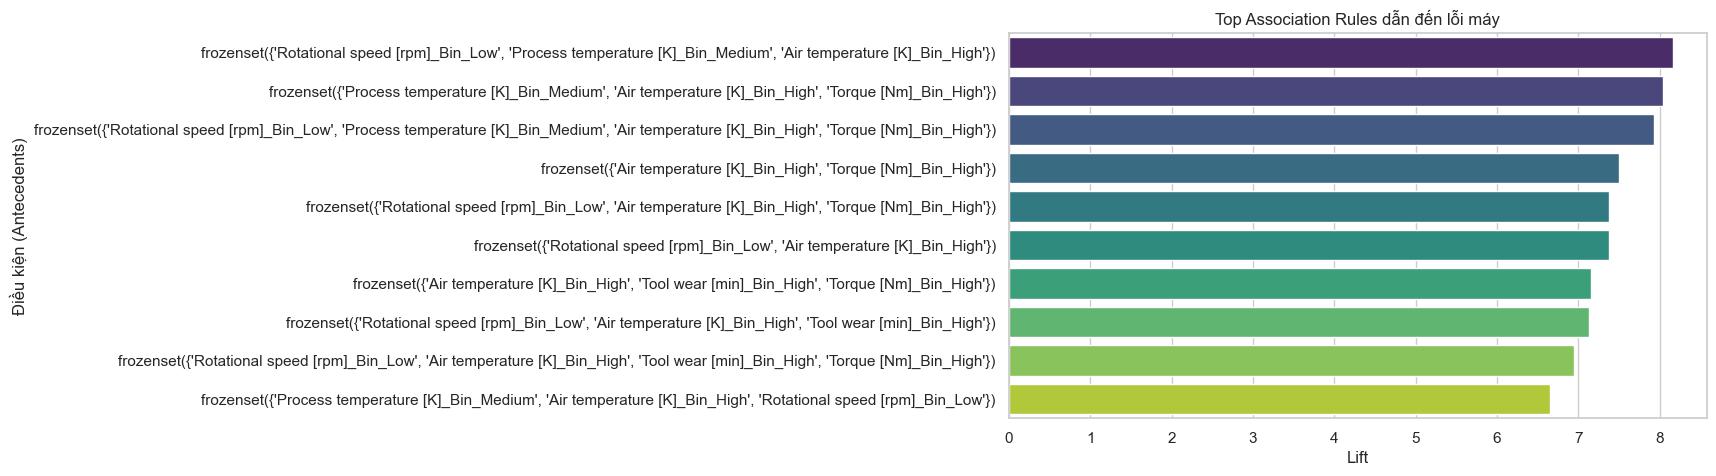

In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# tạo thư mục nếu chưa có (tránh lỗi save)
os.makedirs('images', exist_ok=True)

# lấy top luật theo lift
top_rules = failure_rules.sort_values(by='lift', ascending=False).head(10)

plt.figure(figsize=(9,5))

sns.barplot(
    x=top_rules['lift'],
    y=top_rules['antecedents'].astype(str),
    palette='viridis'
)

plt.title('Top Association Rules dẫn đến lỗi máy', fontsize=12)
plt.xlabel('Lift')
plt.ylabel('Điều kiện (Antecedents)')

plt.tight_layout()

# lưu ảnh (dpi cao cho đẹp khi đưa vào PDF)
plt.savefig('images/association_rules.png', dpi=300)

plt.show()

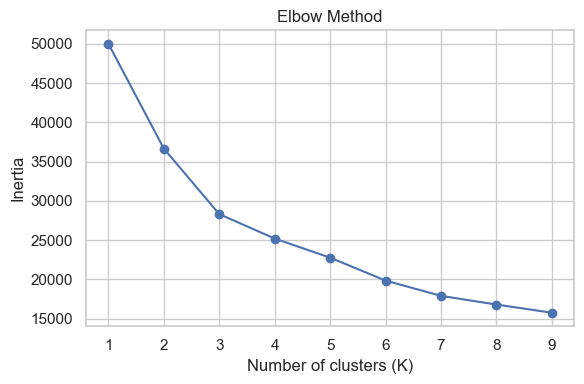

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import os

os.makedirs('images', exist_ok=True)

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')

plt.tight_layout()
plt.savefig('images/elbow.png', dpi=300)
plt.show()

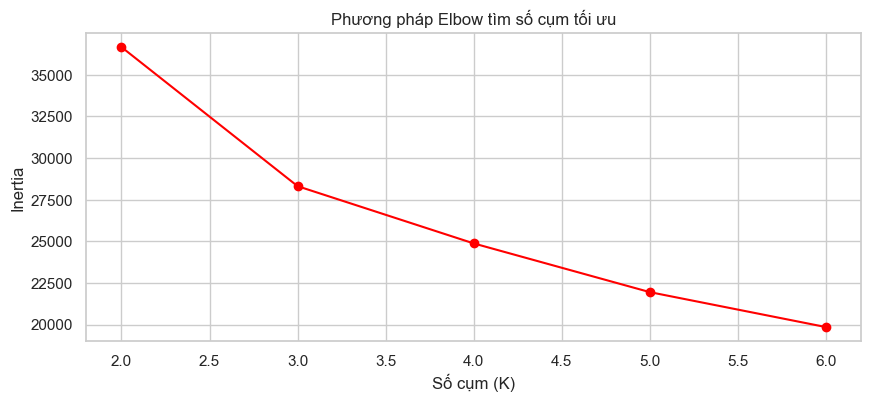

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure_Rate_%,Count
Cluster,,,,,,,
0,301.723308,311.246590,1469.807379,43.643333,110.358270,5.241730,3930
1,298.264252,308.741524,1474.144884,43.264600,104.624844,2.165795,4017
2,300.121383,310.103166,1797.261568,26.574233,109.850950,2.240623,2053


In [11]:
# 1. Khởi tạo và Chuẩn hóa dữ liệu
cluster_miner = ClusterMiner(n_clusters=3) # Giả sử chọn K=3
X_scaled = cluster_miner.preprocess(df, cols_obs)

# 2. Tìm K tối ưu (Vẽ biểu đồ Elbow)
inertia, sil_scores = cluster_miner.find_optimal_k(X_scaled)

plt.figure(figsize=(10, 4))
plt.plot(range(2, 7), inertia, marker='o', color='red')
plt.title('Phương pháp Elbow tìm số cụm tối ưu')
plt.xlabel('Số cụm (K)')
plt.ylabel('Inertia')
plt.show()

# 3. Chạy phân cụm và gán nhãn
df_clustered = cluster_miner.fit_predict(df, X_scaled)

# 4. Profiling (Xem đặc điểm từng nhóm máy)
profile = cluster_miner.profile_clusters(df_clustered)
display(profile)

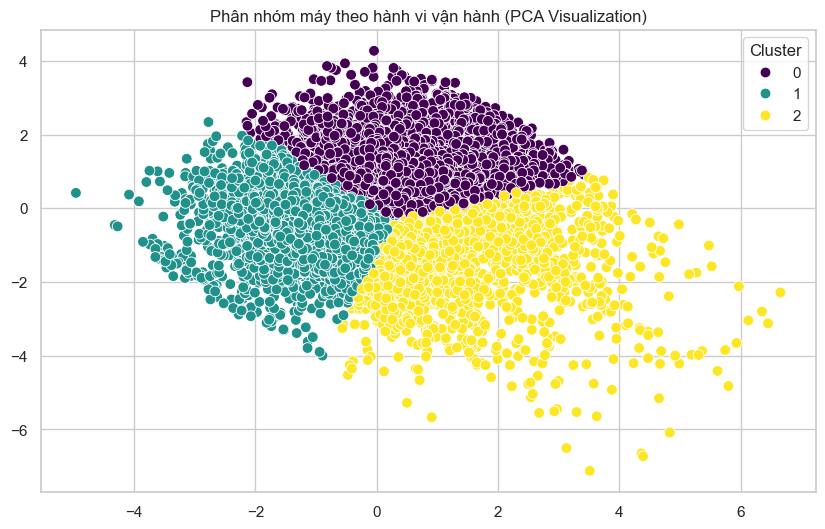

In [6]:
# Giảm chiều xuống 2D để vẽ
X_pca = cluster_miner.get_pca_2d(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_clustered['Cluster'], palette='viridis', s=60)
plt.title('Phân nhóm máy theo hành vi vận hành (PCA Visualization)')
plt.show()